# Unit 4 — GQA: The KV-Cache Memory Math

**Thesis:** Unit 2 revealed the footprint — 9 query heads, 3 KV heads, `K/V = 576/3 = 192`. Unit 3 made attention *position-aware*. Unit 4 asks the question that decides whether an SLM fits on a phone: **how much memory does attention cost per token?**

GQA's answer is one formula:

$$\text{cache bytes} = \text{layers} \times \text{kv\_heads} \times d_k \times 2 \times L \times \text{bytes/float}$$

With SmolLM2's real numbers (30 layers, 3 KV heads, `d_k = 64`) that's **11,520 floats per token** — and we'll prove the `9/3 = 3×` saving against full MHA on actual weights and actual bytes.

In [1]:
# Setup — same as Units 2-3 (self-contained)
import numpy as np
import torch
from transformers import AutoModel, AutoTokenizer

model = AutoModel.from_pretrained("HuggingFaceTB/SmolLM2-135M")
tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")

cfg = model.config
n_layers = cfg.num_hidden_layers
n_qh = cfg.num_attention_heads
n_kvh = cfg.num_key_value_heads
d_k = cfg.hidden_size // n_qh
print("layers:", n_layers, "| q heads:", n_qh, "| kv heads:", n_kvh, "| d_k:", d_k)
print("group size (q per kv):", n_qh // n_kvh)

sentence = "the cat sat on the mat"
ids = tokenizer.encode(sentence)
n = len(ids)
X = model.get_input_embeddings().weight[ids].float().detach().numpy()
W_Q = model.layers[0].self_attn.q_proj.weight.detach().float().numpy()
W_K = model.layers[0].self_attn.k_proj.weight.detach().float().numpy()
W_V = model.layers[0].self_attn.v_proj.weight.detach().float().numpy()

Q = X @ W_Q.T; K = X @ W_K.T; V = X @ W_V.T
Q9 = Q.reshape(n, n_qh, d_k)
K3 = K.reshape(n, n_kvh, d_k)
V3 = V.reshape(n, n_kvh, d_k)
print("Q9:", Q9.shape, "| K3:", K3.shape, "| V3:", V3.shape)

C:\Users\Admin\OneDrive\Documents\Research_projects\pico_projects\linear-transformations-attention\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 5591.47it/s]

layers: 30 | q heads: 9 | kv heads: 3 | d_k: 64
group size (q per kv): 3
Q9: (6, 9, 64) | K3: (6, 3, 64) | V3: (6, 3, 64)


## Design space: MHA, GQA, MQA

How many *copies* of K/V does attention keep per layer?

- **MHA** (Vaswani et al., 2017) — every query head has its own K/V head → **9 KV heads**. Maximum freedom, maximum memory.
- **GQA** (Ainslie et al., 2023) — query heads are grouped; each group shares one KV head → **3 KV heads** here. Near-MHA quality at a fraction of the memory.
- **MQA** (Shazeer, 2019) — all query heads share a single KV head → **1 KV head**. Cheapest, but quality drops.

SmolLM2 picks GQA with `n_q / n_kv = 9 / 3 = 3`. That "3" is the **group size** — the exact memory multiplier GQA saves vs MHA.


In [2]:
print("layers:", n_layers)                    # 30  — the cache repeats per layer
print("query heads:", n_qh)                   # 9   — each asks its own question
print("KV heads:", n_kvh)                     # 3   — the shared content copies
print("d_k:", d_k)                            # 64  — head width
print("group size (q per kv):", n_qh // n_kvh)  # 3  — the memory multiplier saved
print("MHA keeps", n_qh, "KV heads | GQA keeps", n_kvh, "| MQA keeps 1")

layers: 30
query heads: 9
KV heads: 3
d_k: 64
group size (q per kv): 3
MHA keeps 9 KV heads | GQA keeps 3 | MQA keeps 1


## what the KV cache is and why it grows

During generation the model produces one token at a time. Every new token must attend to **all** previous tokens — so the model remembers each past token's K and V at every layer. That memory is the **KV cache**.

Per token, per layer, the cache stores K (`kv_heads × d_k` floats) **and** V (same), so:

$$\text{floats/token} = \text{layers} \times \text{kv\_heads} \times d_k \times 2$$

The cache grows **linearly with sequence length** — this is why long-context inference is memory-hungry, and why `kv_heads` in the formula is the lever GQA pulls.


In [3]:
# per token KV cache cost
floats_gqa = n_layers * n_kvh * d_k * 2          # 30 × 3 × 64 × 2
floats_mha = n_layers * n_qh  * d_k * 2          # 30 × 9 × 64 × 2  (counterfactual)
floats_mqa = n_layers * 1    * d_k * 2           # 30 × 1 × 64 × 2

print("floats/token: GQA", floats_gqa, "| MHA", floats_mha, "| MQA", floats_mqa)
print("fp32 (4 B):   GQA", floats_gqa * 4, "| MHA", floats_mha * 4, "| MQA", floats_mqa * 4)
print("fp16 (2 B):   GQA", floats_gqa * 2, "| MHA", floats_mha * 2, "| MQA", floats_mqa * 2)
print("GQA vs MHA ratio:", floats_mha / floats_gqa)

floats/token: GQA 11520 | MHA 34560 | MQA 3840
fp32 (4 B):   GQA 46080 | MHA 138240 | MQA 15360
fp16 (2 B):   GQA 23040 | MHA 69120 | MQA 7680
GQA vs MHA ratio: 3.0


## Real numbers and the measured proof

SmolLM2's config: 30 layers, 3 KV heads, `d_k = 64`.

```
floats/token     = 30 × 3 × 64 × 2   = 11,520
fp32 (4 B)       = 46,080 B  ≈ 46 KB/token
fp16/bf16 (2 B)  = 23,040 B  ≈ 23 KB/token
2048-token ctx   = 2048 × 23 KB ≈ 47 MB  (fp16)
```

The counterfactual — if SmolLM2 were full MHA (9 KV heads), every factor triples:

```
MHA floats/token = 30 × 9 × 64 × 2 = 34,560  =  3 × GQA
```

The **measured proof**: we don't trust the formula alone. Loop the *real* 30 layers, project our sentence's K/V with each layer's actual weights, count the floats, and compare against the hypothetical 9-head MHA.


In [4]:
#  measured proof on real weights
gqa_floats = 0
for layer in model.layers:
    WK = layer.self_attn.k_proj.weight.detach().float().numpy()
    WV = layer.self_attn.v_proj.weight.detach().float().numpy()
    K_l = X @ WK.T                                # (6, 192)  keys, this layer
    V_l = X @ WV.T                                # (6, 192)  values, this layer
    gqa_floats += K_l.size + V_l.size             # counts real floars stored

mha_floats = n_layers * n * n_qh * d_k * 2        # assumed 9 head MHA

print("GQA real floats (30 layers):", gqa_floats)
print("MHA hypothetical floats:    ", mha_floats)
print("ratio GQA : MHA:", round(mha_floats / gqa_floats, 4))
print("fp_16 full 2048 ctx: GQA %.lf MB | MHA %.lf MB" % (
        2048 * n_layers * n_kvh * d_k * 2 * 2 / 1e6,
        2048 * n_layers * n_qh * d_k * 2 * 2 / 1e6 ))


GQA real floats (30 layers): 69120
MHA hypothetical floats:     207360
ratio GQA : MHA: 3.0
fp_16 full 2048 ctx: GQA 47 MB | MHA 142 MB


## Growth curve

The cache formula is a straight line through zero:

$$\text{bytes}(L) = (\text{layers} \times \text{kv\_heads} \times d_k \times 2 \times \text{bytes/float}) \times L$$

Slope = per-token cost. MHA has slope 3× GQA, MQA 1/3 of GQA. On-device, the horizontal line "what fits in memory" crosses each line at a different max context length.

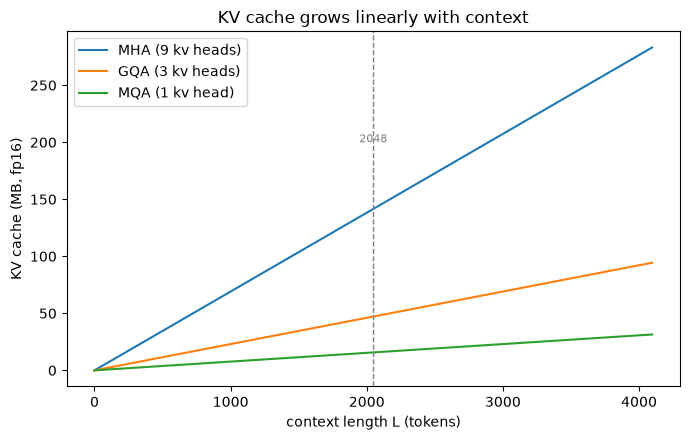

3 straight lines = MHA/GQA/MQA; slope = per-token cost (MHA 3x GQA, MQA 1/3x)
vertical line at L=2048 fp16: MHA ~142 MB | GQA ~47 MB | MQA ~16 MB


In [5]:
import matplotlib.pyplot as plt

L = np.arange(0, 4097, 64)          # context lengths 0..4096
bytes_per_float = 2                 # fp16

def cache_bytes(kv_heads, L):
    return n_layers * kv_heads * d_k * 2 * bytes_per_float * L

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(L, cache_bytes(n_qh, L) / 1e6, label="MHA (9 kv heads)")
ax.plot(L, cache_bytes(n_kvh, L) / 1e6, label="GQA (3 kv heads)")
ax.plot(L, cache_bytes(1, L) / 1e6, label="MQA (1 kv head)")
ax.axvline(2048, color='gray', ls='--', lw=1)
ax.text(2048, 200, "2048", ha='center', fontsize=8, color='gray')
ax.set_xlabel("context length L (tokens)")
ax.set_ylabel("KV cache (MB, fp16)")
ax.set_title("KV cache grows linearly with context")
ax.legend()
plt.tight_layout(); plt.show()
print("3 straight lines = MHA/GQA/MQA; slope = per-token cost (MHA 3x GQA, MQA 1/3x)")
print("vertical line at L=2048 fp16: MHA ~142 MB | GQA ~47 MB | MQA ~16 MB")

## 9→3 sharing, made visible

The grouping rule from Unit 2: `group_of[h] = h // 3`.

```
H0 H1 H2 → KV0
H3 H4 H5 → KV1
H6 H7 H8 → KV2
```

Why is *sharing* the safe part? Queries ask many different questions, so each needs its own projection. But the *content* being read — keys and values — doesn't need 9 copies; 3 well-trained copies serve all 9 questions. That asymmetry is exactly what the narrower `W_K`/`W_V` width (192 vs 576) encodes.

**Your turn → CB 4.5:** plot the group-assignment matrix — 9 query heads × 3 KV heads, colored by which KV head serves which queries.

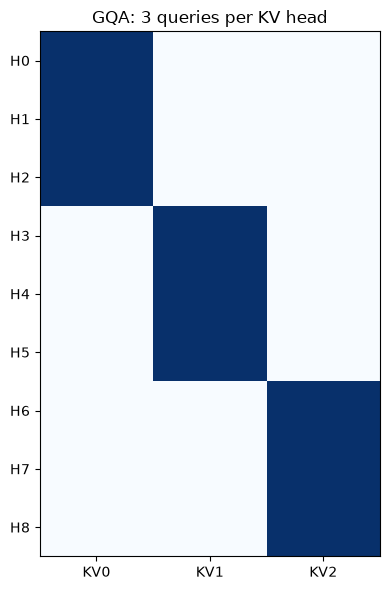

9 rows, 3 blue columns -> each KV serves exactly 3 query heads -> the 3.0x memory saving


In [6]:
G = np.zeros((9, 3))
for h in range(9):
    G[h, h // 3] = 1

fig, ax = plt.subplots(figsize=(4, 6))
ax.imshow(G, cmap="Blues", aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["KV0", "KV1", "KV2"])
ax.set_yticks(range(9)); ax.set_yticklabels([f"H{i}" for i in range(9)])
ax.set_title("GQA: 3 queries per KV head")
plt.tight_layout(); plt.show()
print("9 rows, 3 blue columns -> each KV serves exactly 3 query heads -> the 3.0x memory saving")

## Unit 4 — Conclusion

| Claim (hypothesis) | Predicted | Measured | Verdict |
|---|---|---|---|
| GQA KV width = d_model / 3 | 192 | `W_K`, `W_V` → (192, 576) | ✅ |
| group size = n_q / n_kv = 3 | 9 / 3 | config | ✅ |
| GQA cache = 3× smaller than MHA | ratio 3.0 | measured floats | ✅ |
| cache grows linearly with context | `const × L` | growth graph | ✅ |

**The formula, in one line:**

$$\text{cache bytes} = \text{layers} \times \text{kv\_heads} \times d_k \times 2 \times L \times \text{bytes/float}$$

GQA is the memory lever: it cuts `kv_heads` from 9 to 3, and with it the KV cache for **every token of every layer**. Combined with RoPE (Unit 3 — stateless, trivial cos/sin cache), an SLM gets position-awareness *and* memory efficiency essentially for free.

**Next — repo 2: `matrix-mult-composition-ffn-activations`** — the second block of the decoder layer: the MLP (gate/up/down projections, SiLU) that expands the 576-dim residual stream to 1536 and squeezes it back. Attention + FFN together are the complete decoder layer.

## Industrial note — why the KV cache decides what fits on-device

- **Long context is expensive before it is slow.** Doubling context doubles the KV cache; on a phone with a few GB of shared memory, that limit is usually hit before compute is.
- **GQA is the edge workhorse.** 3× smaller cache than MHA at near-MHA quality — the exact tradeoff SmolLM2 ships.
- **fp16/bf16 halves the bytes** (46 → 23 KB/token) — the reason modern SLMs run in half precision.
- **GQA × RoPE compose**: neither needs a learned per-position table, so both stay cheap as context grows. (Framing only — implementation and benchmarks live in the production repos.)